In [ ]:
!pip install unsloth
!pip install --upgrade transformers
!pip install --no-deps trl

  Using cached transformers-5.5.0-py3-none-any.whl.metadata (32 kB)
Using cached transformers-5.5.0-py3-none-any.whl (10.2 MB)
  Attempting uninstall: transformers
    Found existing installation: transformers 5.5.4
    Uninstalling transformers-5.5.4:
      Successfully uninstalled transformers-5.5.4
  Using cached transformers-5.5.4-py3-none-any.whl.metadata (32 kB)
Using cached transformers-5.5.4-py3-none-any.whl (10.2 MB)
  Attempting uninstall: transformers
    Found existing installation: transformers 5.5.0
    Uninstalling transformers-5.5.0:
      Successfully uninstalled transformers-5.5.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
unsloth-zoo 2026.4.7 requires transformers!=4.52.0,!=4.52.1,!=4.52.2,!=4.52.3,!=4.53.0,!=4.54.0,!=4.55.0,!=4.55.1,!=4.57.4,!=4.57.5,!=5.0.0,!=5.1.0,<=5.5.0,>=4.51.3, but you have transformers 5.5.4 which is incompatible

In [ ]:
import os, re
import torch
from unsloth import FastLanguageModel
import datasets
max_seq_length = 2048
dtype = None
load_in_4bit = True
NUM_CLASSES = 77
from unsloth import tokenizer_utils
def do_nothing(*args, **kwargs):
    pass
tokenizer_utils.fix_untrained_tokens = do_nothing

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!


In [ ]:
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = "unsloth/Llama-3.2-1B-Instruct",
    max_seq_length = max_seq_length,
    dtype = dtype,
    load_in_4bit = load_in_4bit,
)

==((====))==  Unsloth 2026.4.5: Fast Llama patching. Transformers: 5.5.4.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/1.10G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/234 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/17.2M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/454 [00:00<?, ?B/s]

Unsloth: Will load unsloth/llama-3.2-1b-instruct-unsloth-bnb-4bit as a legacy tokenizer.


In [ ]:
number_token_ids = []
for i in range(0, NUM_CLASSES+1):
    number_token_ids.append(tokenizer.encode(str(i), add_special_tokens=False)[0])
# keep only the number tokens from lm_head
par = torch.nn.Parameter(model.lm_head.weight[number_token_ids, :])

old_shape = model.lm_head.weight.shape
old_size = old_shape[0]
print(par.shape)
print(old_shape)

model.lm_head.weight = par

reverse_map = {value: idx for idx, value in enumerate(number_token_ids)} # will be used later to convert an idx from the old tokenizer to the new lm_head
reverse_map

torch.Size([78, 2048])
torch.Size([128256, 2048])


{15: 0,
 16: 1,
 17: 2,
 18: 3,
 19: 4,
 20: 5,
 21: 6,
 22: 7,
 23: 8,
 24: 9,
 605: 10,
 806: 11,
 717: 12,
 1032: 13,
 975: 14,
 868: 15,
 845: 16,
 1114: 17,
 972: 18,
 777: 19,
 508: 20,
 1691: 21,
 1313: 22,
 1419: 23,
 1187: 24,
 914: 25,
 1627: 26,
 1544: 27,
 1591: 28,
 1682: 29,
 966: 30,
 2148: 31,
 843: 32,
 1644: 33,
 1958: 34,
 1758: 35,
 1927: 36,
 1806: 37,
 1987: 38,
 2137: 39,
 1272: 40,
 3174: 41,
 2983: 42,
 3391: 43,
 2096: 44,
 1774: 45,
 2790: 46,
 2618: 47,
 2166: 48,
 2491: 49,
 1135: 50,
 3971: 51,
 4103: 52,
 4331: 53,
 4370: 54,
 2131: 55,
 3487: 56,
 3226: 57,
 2970: 58,
 2946: 59,
 1399: 60,
 5547: 61,
 5538: 62,
 5495: 63,
 1227: 64,
 2397: 65,
 2287: 66,
 3080: 67,
 2614: 68,
 3076: 69,
 2031: 70,
 6028: 71,
 5332: 72,
 5958: 73,
 5728: 74,
 2075: 75,
 4767: 76,
 2813: 77}

In [ ]:
model = FastLanguageModel.get_peft_model(
    model,
    r = 16,
     target_modules = [
        "lm_head",
        "q_proj", "k_proj", "v_proj", "o_proj",
        "gate_proj", "up_proj", "down_proj",],

    lora_alpha = 32,
    lora_dropout = 0,
    bias = "none",

    use_gradient_checkpointing = "unsloth",
    random_state = 3407,
    use_rslora = True,
    loftq_config = None,
)

/usr/local/lib/python3.12/dist-packages/peft/tuners/tuners_utils.py:919: UserWarning: Model with `tie_word_embeddings=True` and the tied_target_modules=['lm_head'] are part of the adapter. This can lead to complications, for example when merging the adapter or converting your model to formats other than safetensors. See for example https://github.com/huggingface/peft/issues/2018.
  warnings.warn(
Unsloth 2026.4.5 patched 16 layers with 16 QKV layers, 16 O layers and 16 MLP layers.


7000


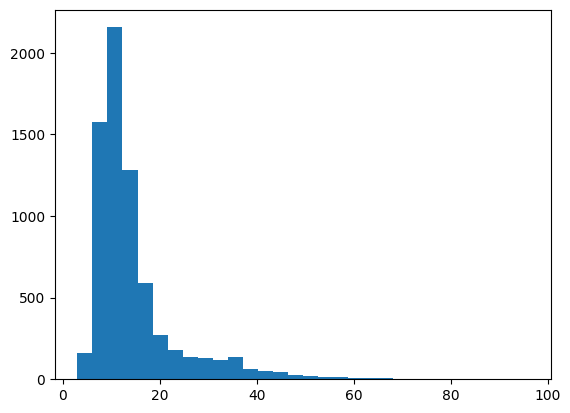

In [ ]:
import json
import pandas as pd
import matplotlib.pyplot as plt

train_df = pd.read_csv("sample_data/train.csv")

print(len(train_df))
token_counts = [len(tokenizer.encode(x)) for x in train_df.text]
# plot the token counts
a = plt.hist(token_counts, bins=30)


In [ ]:
prompt = """Here is a banking query:
{}

Classify this query into one of the following intents:

class 0: activate_my_card
class 1: age_limit
class 2: apple_pay_or_google_pay
class 3: atm_supportuô
class 4: automatic_top_up
class 5: balance_not_updated_after_bank_transfer
class 6: balance_not_updated_after_cheque_or_cash_deposit
class 7: beneficiary_not_allowed
class 8: cancel_transfer
class 9: card_about_to_expire
class 10: card_acceptance
class 11: card_arrival
class 12: card_delivery_estimate
class 13: card_linking
class 14: card_not_working
class 15: card_payment_fee_charged
class 16: card_payment_not_recognised
class 17: card_payment_wrong_exchange_rate
class 18: card_swallowed
class 19: cash_withdrawal_charge
class 20: cash_withdrawal_not_recognised
class 21: change_pin
class 22: compromised_card
class 23: contactless_not_working
class 24: country_support
class 25: declined_card_payment
class 26: declined_cash_withdrawal
class 27: declined_transfer
class 28: direct_debit_payment_not_recognised
class 29: disposable_card_limits
class 30: edit_personal_details
class 31: exchange_charge
class 32: exchange_rate
class 33: exchange_via_app
class 34: extra_charge_on_statement
class 35: failed_transfer
class 36: fiat_currency_support
class 37: get_disposable_virtual_card
class 38: get_physical_card
class 39: getting_spare_card
class 40: getting_virtual_card
class 41: lost_or_stolen_card
class 42: lost_or_stolen_phone
class 43: order_physical_card
class 44: passcode_forgotten
class 45: pending_card_payment
class 46: pending_cash_withdrawal
class 47: pending_top_up
class 48: pending_transfer
class 49: pin_blocked
class 50: receiving_money
class 51: Refund_not_showing_up
class 52: request_refund
class 53: reverted_card_payment?
class 54: supported_cards_and_currencies
class 55: terminate_account
class 56: top_up_by_bank_transfer_charge
class 57: top_up_by_card_charge
class 58: top_up_by_cash_or_cheque
class 59: top_up_failed
class 60: top_up_limits
class 61: top_up_reverted
class 62: topping_up_by_card
class 63: transaction_charged_twice
class 64: transfer_fee_charged
class 65: transfer_into_account
class 66: transfer_not_received_by_recipient
class 67: transfer_timing
class 68: unable_to_verify_identity
class 69: verify_my_identity
class 70: verify_source_of_funds
class 71: verify_top_up
class 72: virtual_card_not_working
class 73: visa_or_mastercard
class 74: why_verify_identity
class 75: wrong_amount_of_cash_received
class 76: wrong_exchange_rate_for_cash_withdrawal

SOLUTION
The correct answer is: class {}"""

def formatting_prompts_func(dataset_):
    texts = []
    for i in range(len(dataset_['text'])):
        text_ = dataset_['text'].iloc[i]
        label_ = dataset_['label'].iloc[i] # the csv is setup so that the label column corresponds exactly to the 3 classes defined above in the prompt (important)

        text = prompt.format(text_, label_)

        texts.append(text)
    return texts
train_df['text'] = formatting_prompts_func(train_df)
train_dataset = datasets.Dataset.from_pandas(train_df,preserve_index=False)


In [ ]:
from typing import Any, Dict, List, Union
from transformers import DataCollatorForLanguageModeling
class DataCollatorForLastTokenLM(DataCollatorForLanguageModeling):
    def __init__(
        self,
        *args,
        mlm: bool = False,
        ignore_index: int = -100,
        **kwargs,
    ):
        super().__init__(*args, mlm=mlm, **kwargs)
        self.ignore_index = ignore_index

    def torch_call(self, examples: List[Union[List[int], Any, Dict[str, Any]]]) -> Dict[str, Any]:
        batch = super().torch_call(examples)

        for i in range(len(examples)):
            # Find the last non-padding token
            last_token_idx = (batch["labels"][i] != self.ignore_index).nonzero()[-1].item()
            # Set all labels to ignore_index except for the last token
            batch["labels"][i, :last_token_idx] = self.ignore_index
            # If the last token in the text is, for example, "2", then this was processed with the old tokenizer into number_token_ids[2]
            # But we don't actually want this because number_token_ids[2] could be something like 27, which is now undefined in the new lm_head. So we map it to the new lm_head index.
            # if this line gives you a keyerror then increase max_seq_length
            batch["labels"][i, last_token_idx] = reverse_map[ batch["labels"][i, last_token_idx].item() ]


        return batch
collator = DataCollatorForLastTokenLM(tokenizer=tokenizer)

In [ ]:
from trl import SFTConfig, SFTTrainer
trainer = SFTTrainer(
    model = model,
    tokenizer = tokenizer,
    train_dataset = train_dataset,
    dataset_text_field = "text",
    max_seq_length = max_seq_length,
    packing = False, # Can make training 5x faster for short sequences.
    args = SFTConfig(
        per_device_train_batch_size = 4,
        gradient_accumulation_steps = 4,
        warmup_steps = 10,
        num_train_epochs = 1, # Set this for 1 full training run.
        learning_rate = 2e-4,
        fp16 = not torch.cuda.is_bf16_supported(),
        bf16 = torch.cuda.is_bf16_supported(),
        logging_steps = 5,
        optim = "adamw_8bit",
        weight_decay = 0.001,
        lr_scheduler_type = "cosine",
        seed = 3407,
        output_dir = "outputs",
        save_strategy="steps",               # Options: "no", "steps", "epoch"
        save_steps=100,                      # Save a checkpoint every 100 steps
        save_total_limit=3,
        report_to = "none", # Use TrackIO/WandB etc
    ),
    data_collator=collator,
)

Unsloth: Tokenizing ["text"] (num_proc=6):   0%|          | 0/7000 [00:00<?, ? examples/s]

In [ ]:
trainer_stats = trainer.train()

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 7,000 | Num Epochs = 1 | Total steps = 438
O^O/ \_/ \    Batch size per device = 4 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (4 x 4 x 1) = 16
 "-____-"     Trainable parameters = 13,357,056 of 1,249,331,200 (1.07% trained)
`use_return_dict` is deprecated! Use `return_dict` instead!


Unsloth: Will smartly offload gradients to save VRAM!


Step,Training Loss
5,4.148709
10,3.197609
15,3.012000
20,2.993387
25,2.643255
30,2.464219
35,2.734192
40,2.606792
45,2.701602
50,2.104614


/usr/local/lib/python3.12/dist-packages/peft/utils/save_and_load.py:279: UserWarning: Setting `save_embedding_layers` to `True` as embedding layers found in `target_modules`.
  warnings.warn("Setting `save_embedding_layers` to `True` as embedding layers found in `target_modules`.")
/usr/local/lib/python3.12/dist-packages/peft/utils/save_and_load.py:279: UserWarning: Setting `save_embedding_layers` to `True` as embedding layers found in `target_modules`.
  warnings.warn("Setting `save_embedding_layers` to `True` as embedding layers found in `target_modules`.")
/usr/local/lib/python3.12/dist-packages/peft/utils/save_and_load.py:279: UserWarning: Setting `save_embedding_layers` to `True` as embedding layers found in `target_modules`.
  warnings.warn("Setting `save_embedding_layers` to `True` as embedding layers found in `target_modules`.")
/usr/local/lib/python3.12/dist-packages/peft/utils/save_and_load.py:279: UserWarning: Setting `save_embedding_layers` to `True` as embedding layers fou

In [ ]:
FastLanguageModel.for_inference(model) # Enable native 2x faster inference
print()

In [ ]:
trimmed_lm_head = model.lm_head.weight.data.clone()
trimmed_lm_head_bias = model.lm_head.bias.data.clone() if hasattr(model.lm_head, "bias") and model.lm_head.bias is not None else torch.zeros(len(number_token_ids), device=trimmed_lm_head.device)

# Create a new lm_head with shape [old_size, hidden_dim]
hidden_dim = trimmed_lm_head.shape[1]
new_lm_head = torch.full((old_size, hidden_dim), 0, dtype=trimmed_lm_head.dtype, device=trimmed_lm_head.device)
new_lm_head_bias = torch.full((old_size,), -1000.0, dtype=trimmed_lm_head_bias.dtype, device=trimmed_lm_head_bias.device)

# Fill in the weights and bias for the allowed tokens (number_token_ids)
for new_idx, orig_token_id in enumerate(number_token_ids):
    new_lm_head[orig_token_id] = trimmed_lm_head[new_idx]
    new_lm_head_bias[orig_token_id] = trimmed_lm_head_bias[new_idx]

# Update the model's lm_head weight and bias
with torch.no_grad():
    new_lm_head_module = torch.nn.Linear(hidden_dim, old_size, bias=True, device=model.device)
    new_lm_head_module.weight.data.copy_(new_lm_head)
    new_lm_head_module.bias.data.copy_(new_lm_head_bias)
    if hasattr(model, "base_model"):
        model.base_model.model.lm_head = new_lm_head_module
    else:
        model.lm_head = new_lm_head_module

print(f"Remade lm_head: shape = {model.lm_head.weight.shape}. Allowed tokens: {number_token_ids}")

Remade lm_head: shape = torch.Size([128256, 2048]). Allowed tokens: [15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 605, 806, 717, 1032, 975, 868, 845, 1114, 972, 777, 508, 1691, 1313, 1419, 1187, 914, 1627, 1544, 1591, 1682, 966, 2148, 843, 1644, 1958, 1758, 1927, 1806, 1987, 2137, 1272, 3174, 2983, 3391, 2096, 1774, 2790, 2618, 2166, 2491, 1135, 3971, 4103, 4331, 4370, 2131, 3487, 3226, 2970, 2946, 1399, 5547, 5538, 5495, 1227, 2397, 2287, 3080, 2614, 3076, 2031, 6028, 5332, 5958, 5728, 2075, 4767, 2813]


In [ ]:
import shutil
from google.colab import files

model.save_pretrained_merged("banking-intent-llama-3.2", tokenizer, save_method = "merged_16bit",)
folder_to_zip = "banking-intent-llama-3.2"
output_filename = "model_trained"
shutil.make_archive(output_filename, 'zip', folder_to_zip)

files.download(f"{output_filename}.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import torch, gc
gc.collect()
torch.cuda.empty_cache()

In [ ]:
import torch
import torch.nn.functional as F
from tqdm import tqdm
import random
model.eval()
# Prepare inference prompt
inference_prompt_template = prompt.split("class {}")[0] + "class "

# Sort validation set by length for efficient batching
test_df = pd.read_csv("sample_data/test.csv")
test_df['token_length'] = test_df['text'].apply(lambda x: len(tokenizer.encode(x, add_special_tokens=False)))
test_df_sorted = test_df.sort_values(by='token_length').reset_index(drop=True)

display = 50
batch_size = 1
device = model.device
correct = 0
results = []

with torch.inference_mode():
    for i in tqdm(range(0, len(test_df_sorted), batch_size), desc="Evaluating"):
        batch = test_df_sorted.iloc[i:i+batch_size]
        prompts = [inference_prompt_template.format(text) for text in batch['text']]
        inputs = tokenizer(prompts, return_tensors="pt", padding=True, truncation=True, max_length=max_seq_length).to(device)
        logits = model(**inputs).logits
        last_idxs = inputs.attention_mask.sum(1) - 1
        last_logits = logits[torch.arange(len(batch)), last_idxs, :]
        probs_all = F.softmax(last_logits, dim=-1)
        probs = probs_all[:, number_token_ids] # only keep the logits for the number tokens
        preds = torch.argmax(probs, dim=-1).cpu().numpy() # looks like [1 1 1 1 3 1 3 1 3 1 1 1 1 2 2 3]

        true_labels = batch['label'].tolist()
        correct += sum([p == t for p, t in zip(preds, true_labels)])
        # Store a few samples for display
        for j in range(len(batch)):
            results.append({
                "text": batch['text'].iloc[j][:200],
                "true": true_labels[j],
                "pred": preds[j],
                "probs": probs[j][1:].float().cpu().numpy(), # ignore prob for class 0 and convert from tensor to float
                "ok": preds[j] == true_labels[j]
            })

            del inputs, logits, last_logits, probs_all, probs

accuracy = 100 * correct / len(test_df_sorted)
print(f"\nValidation accuracy: {accuracy:.2f}% ({correct}/{len(test_df_sorted)})")

print("\n--- Random samples ---")
for s in random.sample(results, min(display, len(results))):
    print(f"\nText: {s['text']}")
    print(f"True: {s['true']}  Pred: {s['pred']} {'✅' if s['ok'] else '❌'}")
    print("Probs:", ", ".join([f"{k}: {v:.3f}" for k, v in enumerate(s['probs'], start=1)]))

# Clean up
if 'token_length' in test_df:
    del test_df['token_length']

Evaluating:   0%|          | 0/700 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
Evaluating: 100%|██████████| 700/700 [03:51<00:00,  3.02it/s]


Validation accuracy: 90.29% (632/700)

--- Random samples ---

Text: I need to update my demographics.
True: 30  Pred: 30 ✅
Probs: 1: 0.000, 2: 0.000, 3: 0.000, 4: 0.000, 5: 0.000, 6: 0.000, 7: 0.000, 8: 0.000, 9: 0.000, 10: 0.000, 11: 0.000, 12: 0.000, 13: 0.000, 14: 0.000, 15: 0.000, 16: 0.000, 17: 0.000, 18: 0.000, 19: 0.000, 20: 0.000, 21: 0.000, 22: 0.000, 23: 0.000, 24: 0.000, 25: 0.000, 26: 0.000, 27: 0.000, 28: 0.000, 29: 0.000, 30: 0.999, 31: 0.000, 32: 0.000, 33: 0.000, 34: 0.000, 35: 0.000, 36: 0.000, 37: 0.000, 38: 0.000, 39: 0.000, 40: 0.000, 41: 0.000, 42: 0.000, 43: 0.000, 44: 0.000, 45: 0.000, 46: 0.000, 47: 0.000, 48: 0.000, 49: 0.000, 50: 0.000, 51: 0.000, 52: 0.000, 53: 0.000, 54: 0.000, 55: 0.000, 56: 0.000, 57: 0.000, 58: 0.000, 59: 0.000, 60: 0.000, 61: 0.000, 62: 0.000, 63: 0.000, 64: 0.000, 65: 0.000, 66: 0.000, 67: 0.000, 68: 0.000, 69: 0.000, 70: 0.000, 71: 0.000, 72: 0.000, 73: 0.000, 74: 0.000, 75: 0.000, 76: 0.000, 77: 0.000

Text: Some cash has been withd